<a href="https://colab.research.google.com/github/Manimech121/Machine_Learning_Projects/blob/main/Yulu_Bikes_Case_study.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Defining problem statement and analysizing basics metrics

Business Problem

Yulu has recently suffered considerable dips in its revenues. They have contracted a consulting company to understand the factors on which the demand for these shared electric cycles depends. Specifically, they want to understand the factors affecting the demand for these shared electric cycles in the Indian market.

The company wants to know :-

Which variables are significant in predicting the demand for shared electric cycles in the Indian market ?
How well those variables describe the electric cycle demands ?

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import math

In [ ]:
!wget https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/001/428/original/bike_sharing.csv

--2025-07-22 01:17:50--  https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/001/428/original/bike_sharing.csv
Resolving d2beiqkhq929f0.cloudfront.net (d2beiqkhq929f0.cloudfront.net)... 13.226.65.83, 13.226.65.68, 13.226.65.32, ...
Connecting to d2beiqkhq929f0.cloudfront.net (d2beiqkhq929f0.cloudfront.net)|13.226.65.83|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 648353 (633K) [text/plain]
Saving to: ‘bike_sharing.csv’

bike_sharing.csv    100%[===================>] 633.16K  3.69MB/s    in 0.2s    

2025-07-22 01:17:51 (3.69 MB/s) - ‘bike_sharing.csv’ saved [648353/648353]



In [ ]:
# converting data in to Dataset
yulu = pd.read_csv("bike_sharing.csv")

In [ ]:
# making an copy of the dataset
df = yulu.copy()

Analysing the basic metrics

In [ ]:
df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [ ]:
# No of rows & columns
df.shape

(10886, 12)

In [ ]:
# Data info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB


In [ ]:
# Checking of null values
yulu.isna().sum()

,0
datetime,0
season,0
holiday,0
workingday,0
weather,0
temp,0
atemp,0
humidity,0
windspeed,0
casual,0


In [ ]:
# Duplicate values check
df.duplicated().sum()

np.int64(0)

In [ ]:
# Uniques values of each columns
df.nunique()

,0
datetime,10886
season,4
holiday,2
workingday,2
weather,4
temp,49
atemp,60
humidity,89
windspeed,28
casual,309


In [ ]:
df["season"].value_counts()

,count
season,
4,2734
2,2733
3,2733
1,2686


Changing datatype of below attributes : -

datetime - to datetime

season - to categorical

holiday - to categorical

workingday - to categorical

weather - to categorical

In [ ]:
df['datetime'] = pd.to_datetime(df['datetime'])
cat_cols= ['season', 'holiday', 'workingday', 'weather']
for col in cat_cols:
  df[col] = df[col].astype('object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB


In [ ]:
df.nunique()

,0
datetime,10886
season,4
holiday,2
workingday,2
weather,4
temp,49
atemp,60
humidity,89
windspeed,28
casual,309


In [ ]:
def is__unique(i):
  print(df[i].unique())

In [ ]:
cols = ["season","holiday","workingday","weather"]

for ele in cols:
  print(ele)
  print(is__unique(ele))
  print("**************************")

season
[1 2 3 4]
None
**************************
holiday
[0 1]
None
**************************
workingday
[0 1]
None
**************************
weather
[1 2 3 4]
None
**************************


In [ ]:
def distribution(i):
  print(df[i].value_counts(normalize = True)*100)


columns = ["season","holiday","workingday","weather"]

for ele in columns:
  print(ele)
  print()
  print(distribution(ele))
  print("***************************")

season

season
4    25.114826
2    25.105640
3    25.105640
1    24.673893
Name: proportion, dtype: float64
None
***************************
holiday

holiday
0    97.14312
1     2.85688
Name: proportion, dtype: float64
None
***************************
workingday

workingday
1    68.087452
0    31.912548
Name: proportion, dtype: float64
None
***************************
weather

weather
1    66.066507
2    26.033437
3     7.890869
4     0.009186
Name: proportion, dtype: float64
None
***************************


In [ ]:
df.describe()

,datetime,temp,atemp,humidity,windspeed,casual,registered,count
count,10886,10886.00000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000
mean,2011-12-27 05:56:22.399411968,20.23086,23.655084,61.886460,12.799395,36.021955,155.552177,191.574132
min,2011-01-01 00:00:00,0.82000,0.760000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2011-07-02 07:15:00,13.94000,16.665000,47.000000,7.001500,4.000000,36.000000,42.000000
50%,2012-01-01 20:30:00,20.50000,24.240000,62.000000,12.998000,17.000000,118.000000,145.000000
75%,2012-07-01 12:45:00,26.24000,31.060000,77.000000,16.997900,49.000000,222.000000,284.000000
max,2012-12-19 23:00:00,41.00000,45.455000,100.000000,56.996900,367.000000,886.000000,977.000000
std,NaN,7.79159,8.474601,19.245033,8.164537,49.960477,151.039033,181.144454




1.   There are no missing values in the dataset.
2.   Casual and registered attributes might have outliers because their mean and median are very far away to one another and the value of standard deviation is also high which tells us that there is high variance in the data of these attributes.





Minimum datetime and maximum datetime

In [ ]:
print(df['datetime'].min(), df['datetime'].max())
# number of unique values in each categorical columns
df[cat_cols].melt().groupby(['variable', 'value'])[['value']].count()

2011-01-01 00:00:00 2012-12-19 23:00:00


value
variable   value       
holiday    0      10575
           1        311
season     1       2686
           2       2733
           3       2733
           4       2734
weather    1       7192
           2       2834
           3        859
           4          1
workingday 0       3474
           1       7412

Univariate Analysis:

Try establishing a relation between the dependent and independent variable (Dependent “Count” & Independent: Workingday, Weather, Season etc)

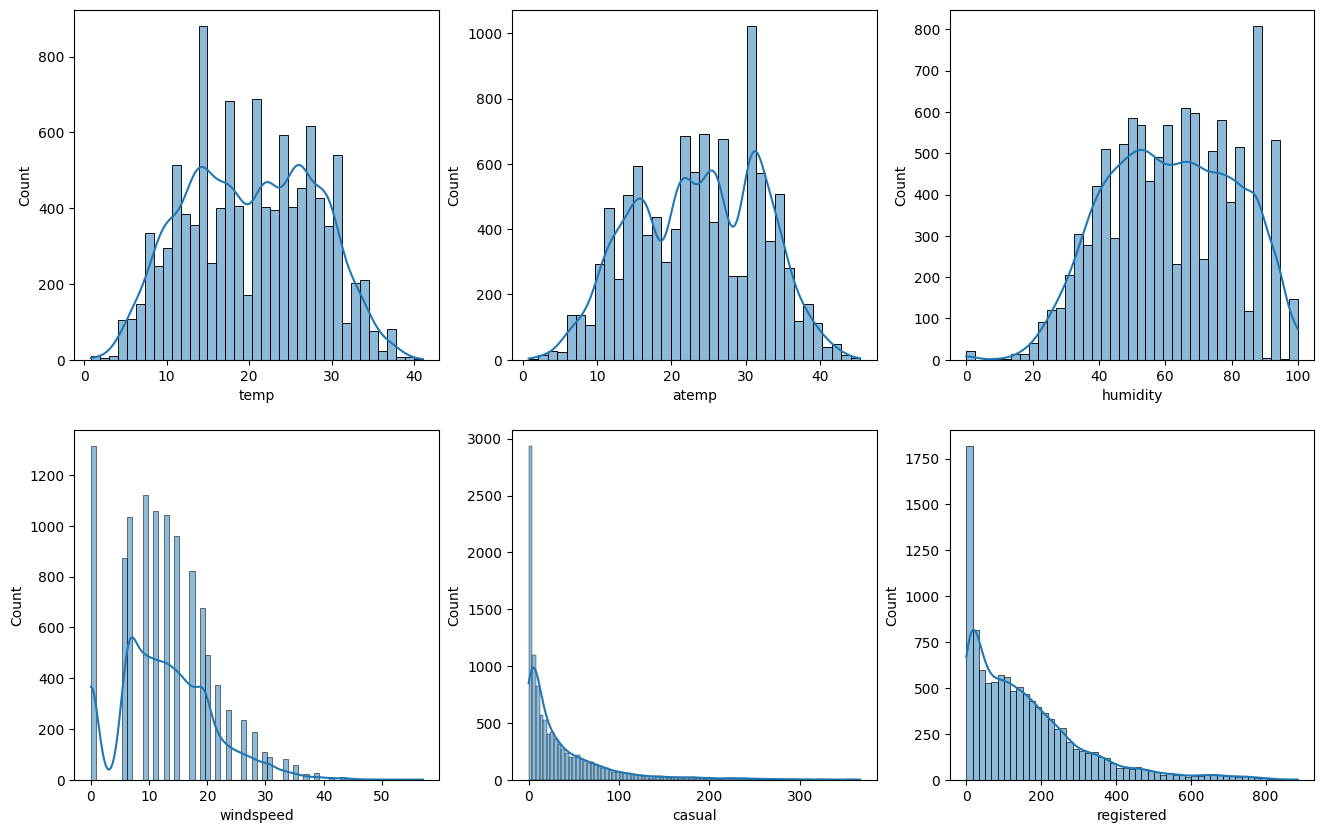

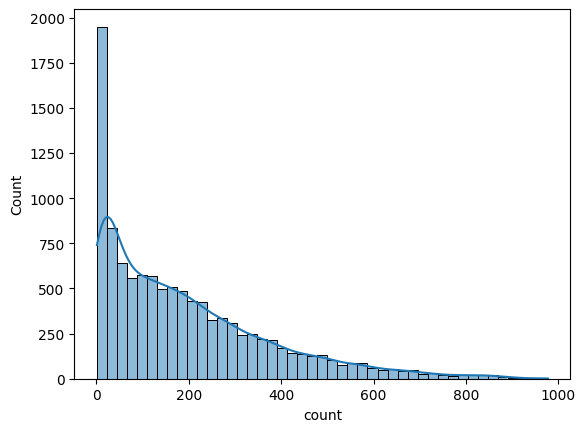

In [ ]:
# understanding the distribution for numerical variables
num_cols = ['temp', 'atemp', 'humidity', 'windspeed', 'casual',
'registered','count']
fig, axis = plt.subplots(nrows=2, ncols=3, figsize=(16, 10))
index = 0
for row in range(2):
  for col in range(3):
    sns.histplot(df[num_cols[index]], ax=axis[row, col], kde=True)
    index += 1
plt.show()
sns.histplot(df[num_cols[-1]], kde=True)
plt.show()



1.   Casual, registered and count somewhat looks like Log Normal Distribution.

2.   Temp, atemp and humidity looks like they follows the Normal Distribution.
Windspeed follows the binomial distribution



Plotting box plots to detect outliers in the data

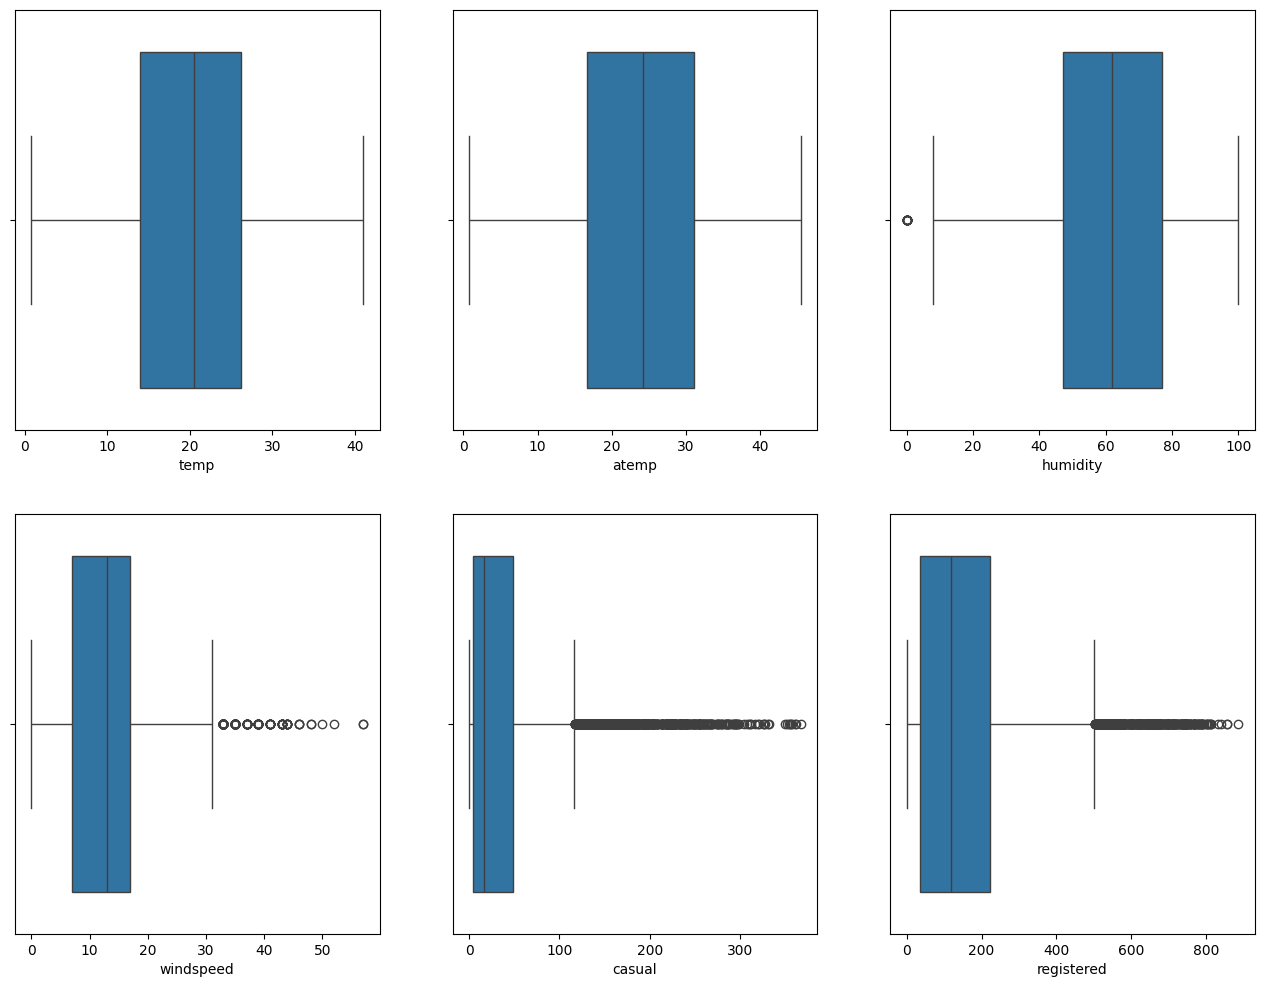

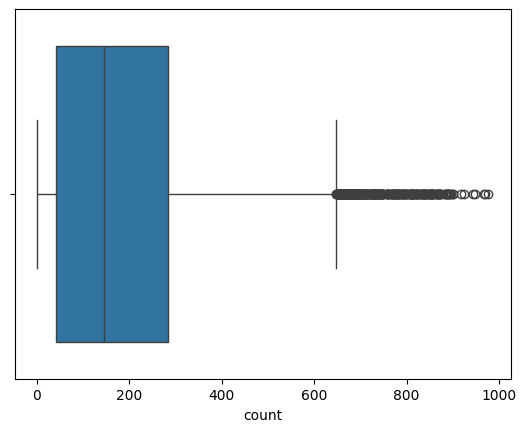

In [ ]:
fig, axis = plt.subplots(nrows=2, ncols=3, figsize=(16, 12))
index = 0
for row in range(2):
  for col in range(3):
    sns.boxplot(x=df[num_cols[index]], ax=axis[row, col])
    index += 1
plt.show()
sns.boxplot(x=df[num_cols[-1]])
plt.show()



1.   Number of casual users and registered users keep changing based on different factors like weather, season. Hence a lot of outliers are seen in these two attributes
2.   Number of casual users and registered users keep changing based on different factors like weather, season. Hence a lot of outliers are seen in these two attributes



Countplot of each categorical column

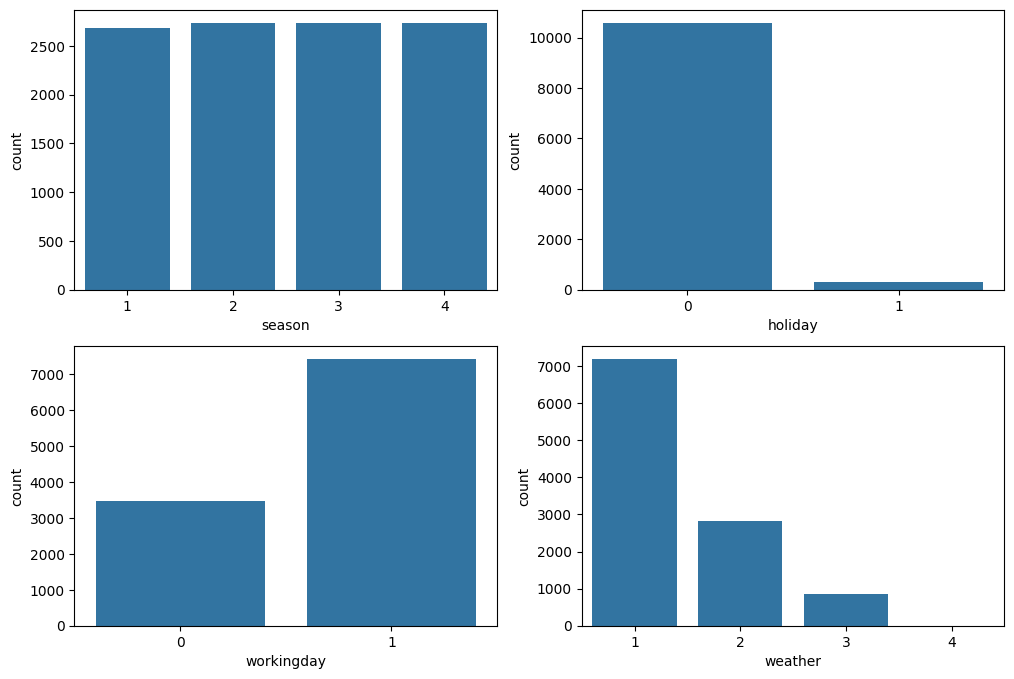

In [ ]:
df.head()

df[df["workingday"] == 1]["count"].sum()

df[(df["workingday"] == 1) & (df["registered"])]["count"].sum()


df[df["workingday"] == 0]["count"].sum()

df[df["holiday"] == 1]["count"].sum()


df[df["holiday"] == 0]["count"].sum()


fig, axis = plt.subplots(nrows=2, ncols=2, figsize=(12, 8))
index = 0
for row in range(2):
  for col in range(2):
    sns.countplot(data=df, x=cat_cols[index], ax=axis[row, col])
    index += 1
plt.show()

Data looks common as it should be like equal number of days in each season, more working days and weather is mostly Clear, Few clouds, partly cloudy, partly cloudy.

Bi-variate Analysis

Plotting categorical variables againt count using boxplots

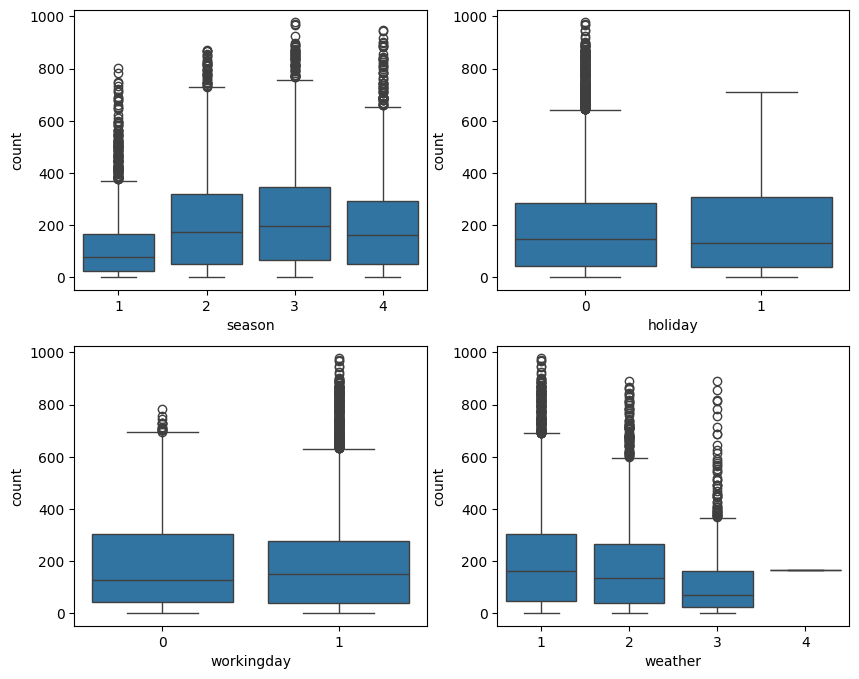

In [ ]:
fig, axis = plt.subplots(nrows=2, ncols=2, figsize=(10, 8))
index = 0
for row in range(2):
  for col in range(2):
    sns.boxplot(data=df, x=cat_cols[index], y='count', ax=axis[row,col])
    index += 1
plt.show()


*   In summer and fall seasons more bikes are rented as compared to other seasons.
*   Whenever its a holiday more bikes are rented.
*   It is also clear from the workingday also that whenever day is holiday or weekend, slightly more bikes were rented.
*  Whenever there is rain, thunderstorm, snow or fog, there were less bikes were rented.


**Plotting numerical variables againt count using scatterplot.**

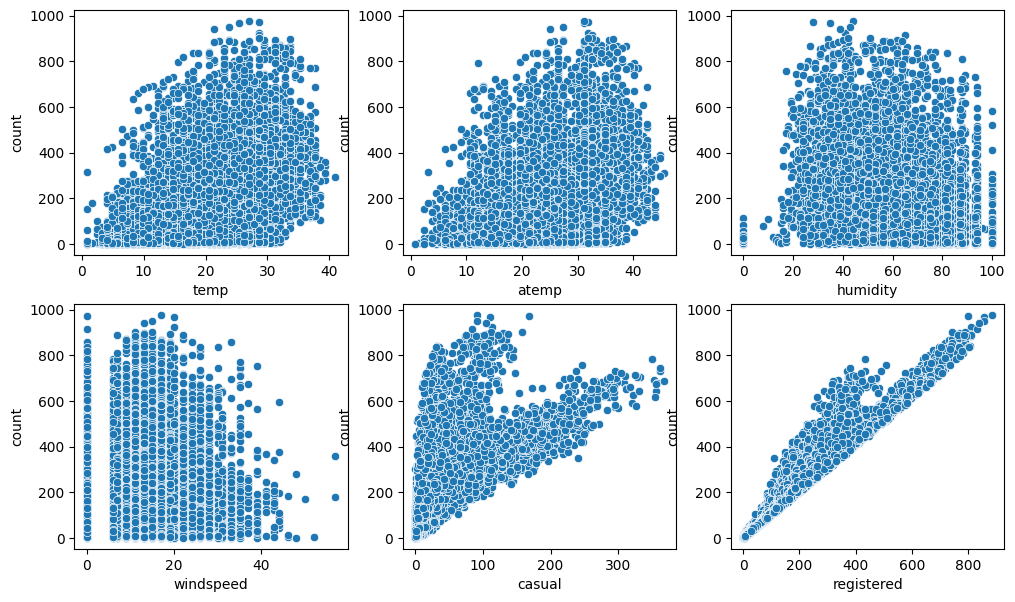

In [ ]:
fig, axis = plt.subplots(nrows=2, ncols=3, figsize=(12, 7))
index = 0
for row in range(2):
  for col in range(3):
    sns.scatterplot(data=df, x=num_cols[index], y='count',ax=axis[row, col])
    index += 1
plt.show()

Whenever the humidity is less than 20, number of bikes rented is very very low.

Whenever the temperature is less than 10, number of bikes rented is less.

Whenever the windspeed is greater than 35, number of bikes rented is less.

**Understanding the correlation between count and numerical variables**

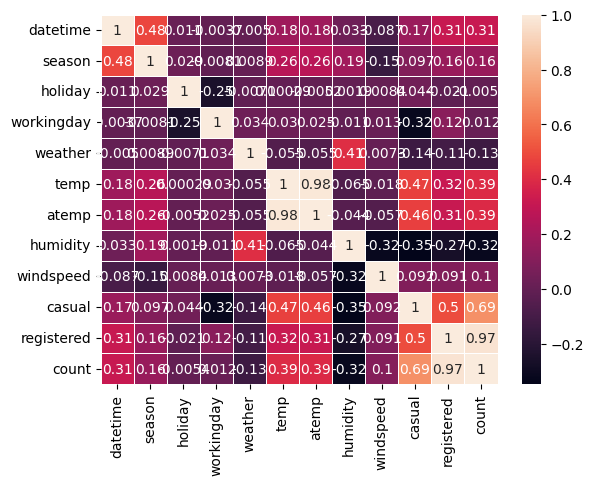

In [ ]:
#df.corr()['count']
sns.heatmap(df.corr(), annot=True, linewidth=.5)
plt.show()

**Hypothesis testing**

**Chi-square test to check if Weather is dependent on the season**



*  Null Hypothesis (H0): Weather is independent of the season
*  Alternate Hypothesis (H1): Weather is dependent on the season
*  Significance level (alpha): 0.05






In [ ]:
data_table = pd.crosstab(df['season'], df['weather'])
print("Observed values:")
data_table

val = stats.chi2_contingency(data_table)
print(val)
print()
print("***********************************************")


Expected_values = val[3]
print(f'Expected_values : {val[3]}')
print()
print("***********************************************")


nrows, ncols = 4, 4
dof = (nrows-1)*(ncols-1)
print(f"Degrees of freedom: {dof}")
print()
print("***********************************************")
alpha = 0.05

chi_sqr = sum([(o-e)**2/e for o, e in zip(data_table.values,Expected_values)])
chi_sqr_statistic = chi_sqr[0] + chi_sqr[1]
print(f"Chi-square test statistic: {chi_sqr_statistic}")
print()
print("***********************************************")


critical_val = stats.chi2.ppf(q=1-alpha, df=dof)
print(f"Critical value: {critical_val}")
print()
print("***********************************************")

p_val = 1-stats.chi2.cdf(x=chi_sqr_statistic, df=dof)
print(f"P-value: {p_val}")
print()
print("***********************************************")


if p_val <= alpha:
  print("Since p-value is less than the alpha 0.05 we reject Null Hypothesis. This indicates weather is dependent on the season.")
else:
  print("Since p-value is greater than the alpha 0.05 we do not reject the Null Hypothesis")

Observed values:
Chi2ContingencyResult(statistic=np.float64(49.158655596893624), pvalue=np.float64(1.549925073686492e-07), dof=9, expected_freq=array([[1.77454639e+03, 6.99258130e+02, 2.11948742e+02, 2.46738931e-01],
       [1.80559765e+03, 7.11493845e+02, 2.15657450e+02, 2.51056403e-01],
       [1.80559765e+03, 7.11493845e+02, 2.15657450e+02, 2.51056403e-01],
       [1.80625831e+03, 7.11754180e+02, 2.15736359e+02, 2.51148264e-01]]))

***********************************************
Expected_values : [[1.77454639e+03 6.99258130e+02 2.11948742e+02 2.46738931e-01]
 [1.80559765e+03 7.11493845e+02 2.15657450e+02 2.51056403e-01]
 [1.80559765e+03 7.11493845e+02 2.15657450e+02 2.51056403e-01]
 [1.80625831e+03 7.11754180e+02 2.15736359e+02 2.51148264e-01]]

***********************************************
Degrees of freedom: 9

***********************************************
Chi-square test statistic: 44.09441248632364

***********************************************
Critical value: 16.918977604

2- Sample T-Test to check if Working Day has an effect on the number of electric cycles rented :



*   Null Hypothesis: Working day has no effect on the number of cycles being rented
.
*   Alternate Hypothesis: Working day has effect on the number of cycles being rented.



*   
Significance level (alpha): 0.05



In [ ]:
data_group1 = df[df['workingday']==0]['count'].values
data_group2 = df[df['workingday']==1]['count'].values
print(np.var(data_group1), np.var(data_group2))
np.var(data_group2)// np.var(data_group1)

30171.346098942427 34040.69710674686


np.float64(1.0)

Before conducting the two-sample T-Test we need to find if the given data groups have the same variance. If the ratio of the larger data groups to the small data group is less than 4:1 then we can consider that the given data groups have equal variance.

In [ ]:
stats.ttest_ind(a=data_group1, b=data_group2, equal_var=True)

TtestResult(statistic=np.float64(-1.2096277376026694), pvalue=np.float64(0.22644804226361348), df=np.float64(10884.0))

Since pvalue is greater than 0.05 so we cannot reject the Null hypothesis. We don't have the sufficient evidence to say that working day has effect on the number of cycles being rented.

**ANNOVA to check if No. of cycles rented is similar or different in different weather and season**



*   Null Hypothesis: Number of cycles rented is similar in different weather and season.
*   Alternate Hypothesis: Number of cycles rented is not similar in different weather and season.


*   Significance level (alpha): 0.05





**Weather check**

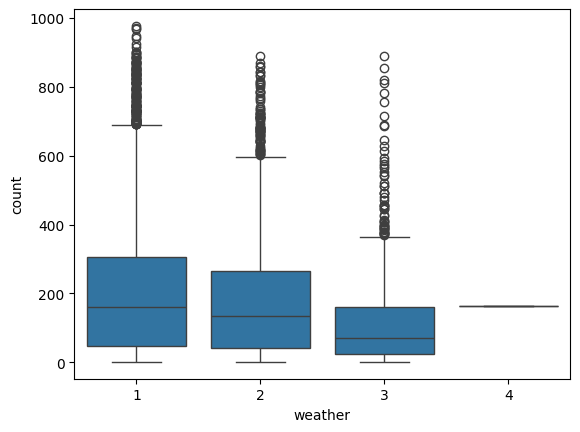

205.24 178.96 118.85 164.0


In [ ]:
df["weather"].unique()

df["weather"].value_counts()

sns.boxplot(x='weather', y='count', data=df)
plt.show()

count_g1 = df[df["weather"]==1]["count"]
count_g2 = df[df["weather"]==2]["count"]
count_g3 = df[df["weather"]==3]["count"]
count_g4 = df[df["weather"]==4]["count"]

a,b,c,d = [round(count_g1.mean(), 2),round(count_g2.mean(),2),round(count_g3.mean(),2),round(count_g4.mean(),2)]

print(a, end= " ")
print(b, end= " ")
print(c, end= " ")
print(d)

In [ ]:
from scipy.stats import f_oneway, kruskal   # Numeric Vs categorical for many categories

# H0: All weather's have same number of cycles rented.
# Ha: Atleast one or more weather conditions have different number of cycles rented.

f_stats, p_value = f_oneway(count_g1,count_g2,count_g3,count_g4)
print(f"p_value : {p_value}")
print()

if p_value < 0.05:
    print("Reject H0")
    print("Different weathers have different number of cycles rented")
else:
    print("Fail to reject H0 or accept H0")
    print("All weather's have same number of cycles rented.")

p_value : 5.482069475935669e-42

Reject H0
Different weathers have different number of cycles rented


Since P-value is very less we reject the null hypothesis. Atleast one or more weather conditions have different number of cycles rented.






**Season check**

In [ ]:
df["season"].unique()

array([1, 2, 3, 4], dtype=object)

In [ ]:
df["season"].value_counts()

,count
season,
4,2734
2,2733
3,2733
1,2686


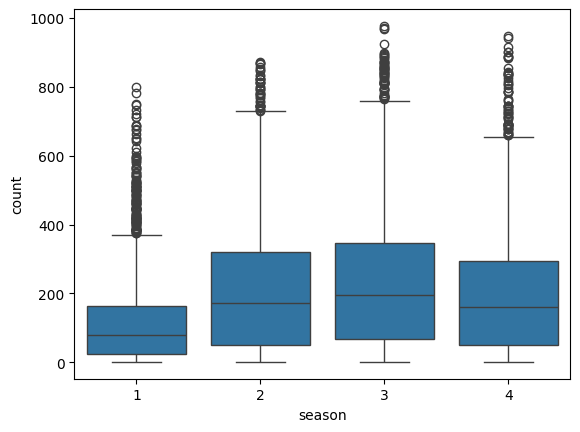

In [ ]:
sns.boxplot(x='season', y='count', data=df)
plt.show()

In [ ]:
coun_g1 = df[df["season"]==1]["count"]
coun_g2 = df[df["season"]==2]["count"]
coun_g3 = df[df["season"]==3]["count"]
coun_g4 = df[df["season"]==4]["count"]

a,b,c,d = [round(coun_g1.mean(), 2),round(coun_g2.mean(),2),round(coun_g3.mean(),2),round(coun_g4.mean(),2)]

print(a, end= " ")
print(b, end= " ")
print(c, end= " ")
print(d)

116.34 215.25 234.42 198.99


In [ ]:
from scipy.stats import f_oneway, kruskal   # Numeric Vs categorical for many categories

# H0: All seasons's have same number of cycles rented.
# Ha: Atleast one or more seasons  have different number of cycles rented.

f_stats, p_value = f_oneway(coun_g1,coun_g2,coun_g3,coun_g4)
print(f"p_value : {p_value}")
print()

if p_value < 0.05:
    print("Reject H0")
    print("Different seasons have different number of cycles rented")
else:
    print("Fail to reject H0 or accept H0")
    print("All seasons have same number of cycles rented.")

p_value : 6.164843386499654e-149

Reject H0
Different seasons have different number of cycles rented


**Checking Assumptions of Anova test**






QQ plot and histogram for weather

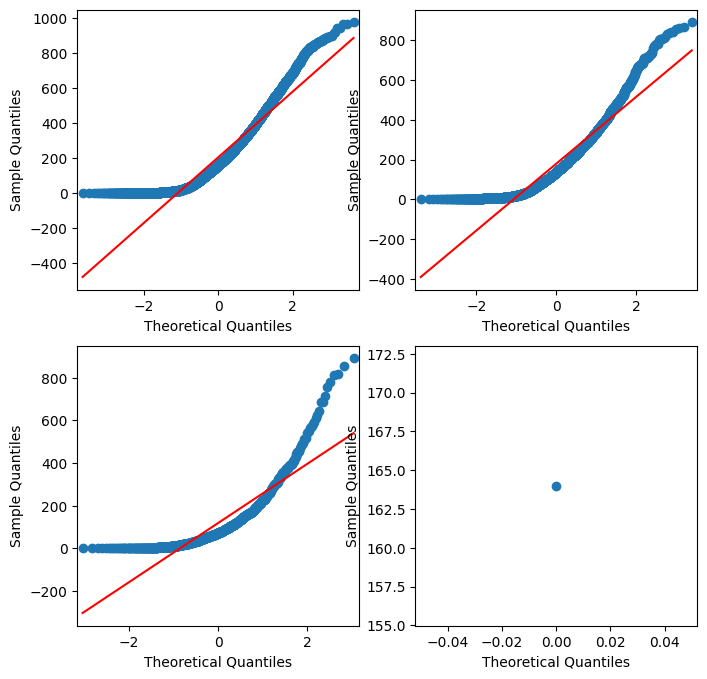

In [ ]:
import numpy as np
import statsmodels.api as sm
import pylab as py

a = [count_g1,count_g2,count_g3,count_g4]

fig, axis = plt.subplots(nrows=2, ncols=2, figsize=(8, 8))

sm.qqplot(a[0], line = "s", ax = axis[0,0])
sm.qqplot(a[1], line = "s", ax = axis[0,1])
sm.qqplot(a[2], line = "s", ax = axis[1,0])
sm.qqplot(a[3], line = "s", ax = axis[1,1])

plt.show()

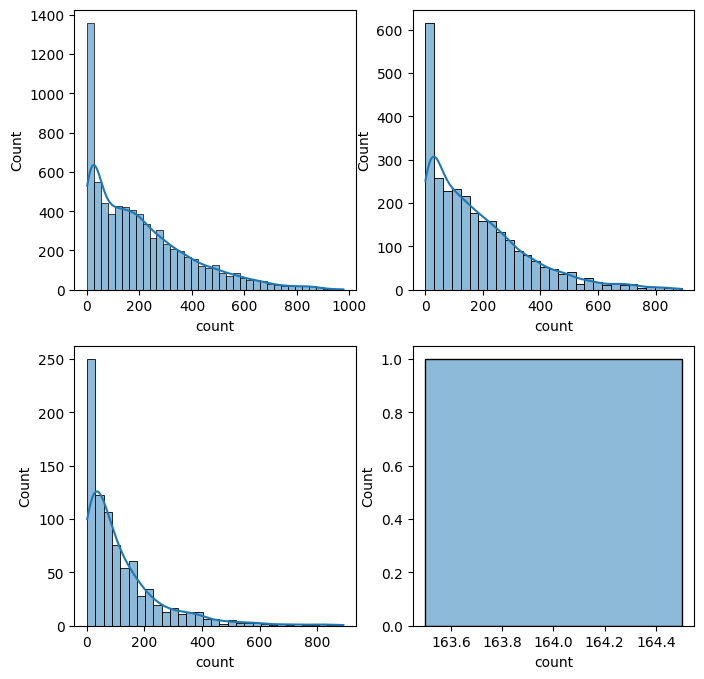

In [ ]:
a = [count_g1,count_g2,count_g3,count_g4]

fig, axis = plt.subplots(nrows=2, ncols=2, figsize=(8, 8))

index = 0
for row in range(2):
  for col in range(2):
    sns.histplot(a[index], ax=axis[row, col], kde=True)
    index += 1
plt.show()



QQ plot and histogram for season.

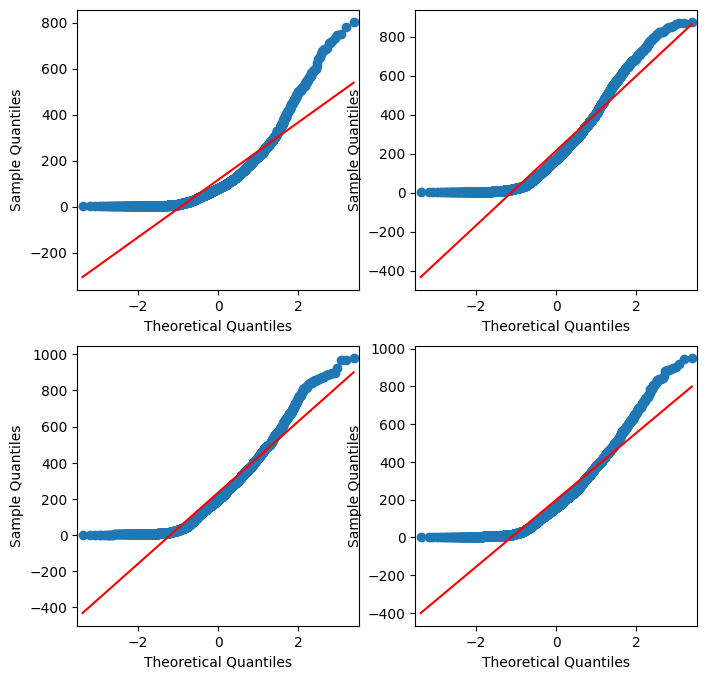

In [ ]:
b = [coun_g1,coun_g2,coun_g3,coun_g4]

fig, axis = plt.subplots(nrows=2, ncols=2, figsize=(8, 8))

sm.qqplot(b[0], line = "s", ax = axis[0,0])
sm.qqplot(b[1], line = "s", ax = axis[0,1])
sm.qqplot(b[2], line = "s", ax = axis[1,0])
sm.qqplot(b[3], line = "s", ax = axis[1,1])

plt.show()

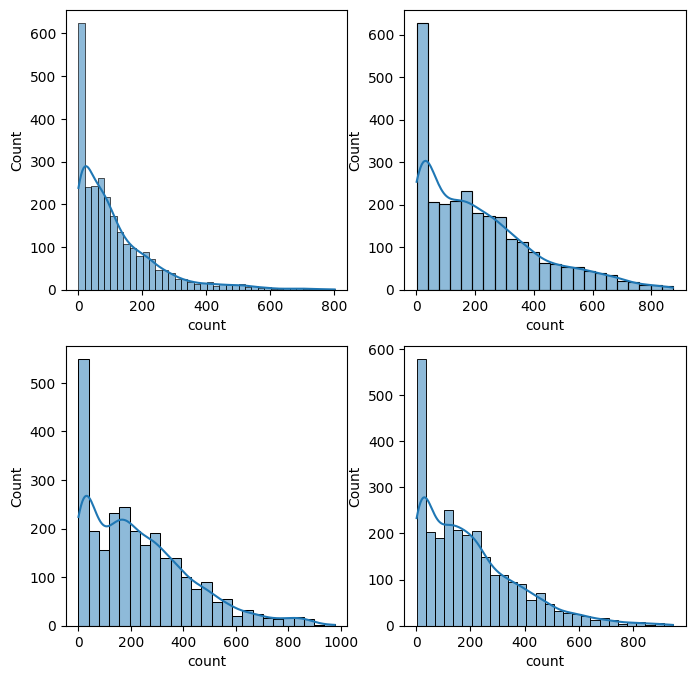

In [ ]:
b = [coun_g1,coun_g2,coun_g3,coun_g4]

fig, axis = plt.subplots(nrows=2, ncols=2, figsize=(8, 8))

index = 0
for row in range(2):
  for col in range(2):
    sns.histplot(b[index], ax=axis[row, col], kde=True)
    index += 1
plt.show()

The above plots show data is not gaussian. Let us confirm the same via statiscal test.


Shapiro-Wilk test for Gaussian (Statistical Test for Normality)

Weather data

In [ ]:
count_g1_subset = count_g1.sample(100)

# H0: Data is Gaussian
# Ha: Data is not Gaussian
from scipy.stats import shapiro
from scipy.stats import levene

test_stat, p_value = shapiro(count_g1_subset)
print(p_value)
if p_value<0.05:
    print("Data is not gaussian")
else:
    print("Data is gaussian")

2.5485368028334156e-07
Data is not gaussian


Season data


In [ ]:
coun_g1_subset = coun_g1.sample(100)

# H0: Data is Gaussian
# Ha: Data is not Gaussian
from scipy.stats import shapiro
from scipy.stats import levene

test_stat, p_value = shapiro(coun_g1_subset)
print(p_value)
if p_value<0.05:
    print("Data is not gaussian")
else:
    print("Data is gaussian")

3.777743523451816e-09
Data is not gaussian


Equal variance: Levene's Test



*   Null Hypothesis: Variances is similar in different weather and season.



*  Alternate Hypothesis: Variances is not similar in different weather and season.



*   Significance level (alpha): 0.05




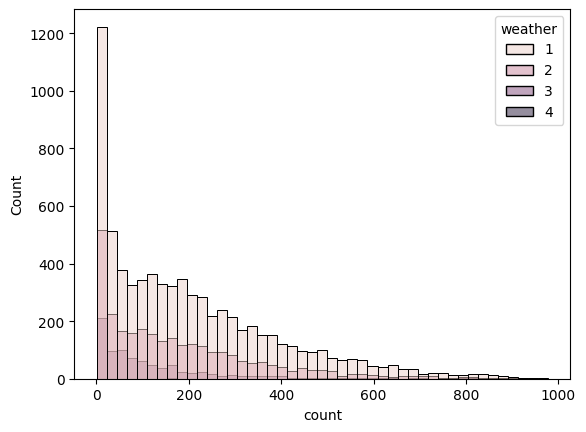

In [ ]:
sns.histplot(data= df, x="count", hue= "weather", color = "o")
plt.show()

In [ ]:
# H0: Variances are equal
# Ha: Variances are not equal
levene_stat, p_value = levene(count_g1,count_g2,count_g3,count_g4)
print(f'p-value : {p_value}')
if p_value < 0.05:
    print("Reject the null hypthesis.Variances are not similar.")
else:
    print("Variance are similar.")

p-value : 3.504937946833238e-35
Reject the null hypthesis.Variances are not similar.


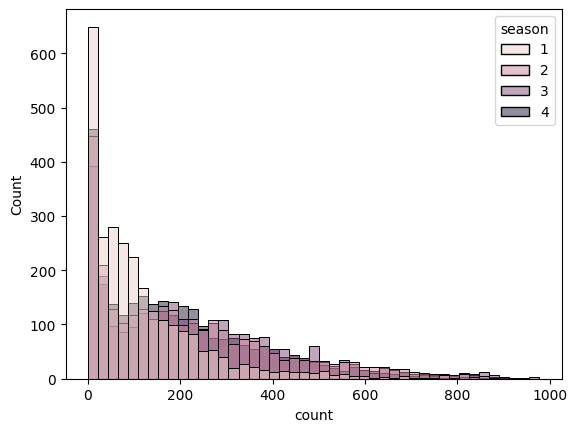

In [ ]:
sns.histplot(data= df, x="count", hue= "season", color = "o")
plt.show()

In [ ]:
# H0: Variances are equal
# Ha: Variances are not equal
levene_stat, p_value = levene(coun_g1,coun_g2,coun_g3,coun_g4)
print(f'p-value : {p_value}')
if p_value < 0.05:
    print("Reject the null hypthesis. Variances are not similar.")
else:
    print("Variance are similar.")

p-value : 1.0147116860043298e-118
Reject the null hypthesis. Variances are not similar.


As per the QQ plots, histograms, Shapiro and Levene test the assumtions of
Anova have failed. Hence we will use Kruskal test



Weather

In [ ]:
kruskal_stat, p_value = stats.kruskal(count_g1,count_g2,count_g3,count_g4)
print(f"p_value : {p_value}")

if p_value<0.05:
  print("Since p-value is less than 0.05, we reject the null hypothesis")
  print('Different weather have different number of cycles rented.')
else :
  print("Failes to reject null hypothesis. All weathers has same number of cycles rented.")

p_value : 3.501611300708679e-44
Since p-value is less than 0.05, we reject the null hypothesis
Different weather have different number of cycles rented.


Season


In [ ]:
kruskal_stat, p_value = stats.kruskal(coun_g1,coun_g2,coun_g3,coun_g4)
print(f"p_value : {p_value}")

if p_value<0.05:
  print("Since p-value is less than 0.05, we reject the null hypothesis")
  print('Different weather have different number of cycles rented.')
else :
  print("Failed to reject null hypothesis. All weathers has same number of cycles rented.")

p_value : 2.479008372608633e-151
Since p-value is less than 0.05, we reject the null hypothesis
Different weather have different number of cycles rented.


**Insights**


**Seasonal Trends**

1.   More bikes are rented during summer and fall compared to other seasons.
2.   The maximum number of holidays occur during fall and winter seasons.

**Holidays and Weekends**

*  There is an increase in bike rentals on holidays.
*   On non-working days (holidays or weekends), slightly more bikes are rented than on working days.
*   A 2-sample t-test on working vs. non-working days suggests that the mean population count of both categories are the same.

**Weather Impact**

*   Fewer bikes are rented during rain, thunderstorm, snow, or fog.

*   An ANOVA test on weather conditions (excluding condition 4) shows that mean bike rental counts are the same, indicating no major difference in usage across weather types.
*   Chi-square test between season and weather indicates that weather patterns depend on the season.

**Environmental Conditions**

*   When humidity is less than 20%, bike rentals are very low.

*   When temperature is less than 10°C, fewer bikes are rented.

*   When windspeed is greater than 35 km/h, bike rentals are reduced.

*   There is a positive correlation between bike rental count and temperature

*   There is a negative correlation between bike rental count and humidity.


**Statistical Test Results Summary**



*  2-Sample T-Test (working vs. non-working days): No significant difference in mean rental count.
*  ANOVA Test (seasons): Significant difference in rental counts — season affects bike usage.


*  ANOVA Test (weather): No significant difference — weather types (except extreme ones) do not greatly affect usage.
*   Chi-square Test (season vs. weather): Shows dependency, indicating seasonal influence on weather.












**Recommendations**

# Yulu Bike Rental – Strategic Recommendations

## 1. Inventory & Fleet Management

- Increase bike stock during high-demand seasons:
  - Summer and Fall have significantly higher rental counts.

- Decrease bike stock during low-demand conditions:
  - Very low humidity days (humidity < 20%)
  - Cold weather (temperature < 10°C)
  - High wind speeds (> 35 km/h)
  - Thunderstorms and heavy rains

- Use historical data and weather forecasts to manage stock dynamically across locations.

---

## 2. Weather-Based Planning

- Regularly monitor seasonal weather forecasts to:
  - Predict and prepare for drops in demand due to rain, storms, cold, or high humidity.
  - Reallocate bikes dynamically to match expected demand.

---

## 3. Marketing & Customer Acquisition

- Focus on acquiring more casual users (currently underrepresented):
  - First-time user discounts
  - Referral bonuses
  - Friends & family packages
  - Loyalty rewards

- Increase engagement on non-working days (holidays/weekends):
  - Weekend promotional offers
  - Festival or event-based campaigns
  - Group ride discounts

---

## 4. Product & Service Innovation

- During heavy rain or extreme weather, consider:
  - Alternate vehicles (e.g., umbrella-attached bikes or mini electric cars)
  - Rental rain gear or accessories
  - Covered shelters at popular pickup/drop points

---

## 5. Data-Driven Strategy Support

- 2-sample T-test result:
  - No significant difference in rental count between working and non-working days.

- ANOVA test on seasons:
  - Significant difference in usage across seasons; seasonality affects demand.

- Chi-square test between season and weather:
  - Indicates weather patterns depend on seasons; align operational planning accordingly.